In [ ]:
import numpy as np
import joblib
import random
import time  # 🕒 시간 측정
from scipy.ndimage import rotate, shift, zoom

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC, LinearSVC  # 🚀 변경 (GradientBoosting → SVM)
from sklearn.preprocessing import StandardScaler  # 🚀 추가
from sklearn.metrics import classification_report, accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV


In [ ]:
# ==========================================
# 1. 사용자 정의 전처리 클래스
# ==========================================
class CustomImagePreprocess(BaseEstimator, TransformerMixin):
    def __init__(self, stroke_target=0.4, target_size=20, final_size=28, noise_threshold=0.02):
        self.stroke_target = stroke_target
        self.target_size = target_size
        self.final_size = final_size
        self.noise_threshold = noise_threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = np.array(X)
        if X.ndim == 2:
            side = int(np.sqrt(X.shape[1]))
            X = X.reshape(-1, side, side)

        processed = []
        for img in X:
            img = self.normalize_scale(img)
            img = self.remove_noise(img)
            img = self.normalize_stroke(img)
            img = self.normalize_size(img)
            img = self.center_align(img)
            processed.append(img)

        processed = np.array(processed)
        return processed.reshape(len(processed), -1)

    # --- 내부 메서드 ---
    def normalize_scale(self, img):
        img = img.astype(np.float32)
        if img.max() > 1: img = img / 255.0
        return img

    def remove_noise(self, img):
        img = img.copy()
        img[img < self.noise_threshold] = 0.0
        return img

    def normalize_stroke(self, img):
        mask = img > 0.05
        if mask.sum() == 0: return img
        mean_val = img[mask].mean()
        if mean_val == 0: return img
        scale_factor = self.stroke_target / mean_val
        img = img * scale_factor
        img = np.clip(img, 0, 1)
        return img

    def normalize_size(self, img):
        coords = np.where(img > 0.05)
        if coords[0].size == 0: return np.zeros((self.final_size, self.final_size))
        r1, r2 = coords[0].min(), coords[0].max()
        c1, c2 = coords[1].min(), coords[1].max()
        digit = img[r1:r2+1, c1:c2+1]
        h, w = digit.shape
        if h == 0 or w == 0: return np.zeros((self.final_size, self.final_size))
        zoom_h = self.target_size / h
        zoom_w = self.target_size / w
        digit_resized = zoom(digit, (zoom_h, zoom_w))
        return digit_resized

    def center_align(self, img):
        canvas = np.zeros((self.final_size, self.final_size))
        h, w = img.shape
        if h > self.final_size or w > self.final_size:
            h_start = (h - self.final_size) // 2
            w_start = (w - self.final_size) // 2
            img = img[h_start:h_start+self.final_size, w_start:w_start+self.final_size]
            h, w = img.shape
        y0 = (self.final_size - h) // 2
        x0 = (self.final_size - w) // 2
        canvas[y0:y0+h, x0:x0+w] = img
        return canvas

In [ ]:
# ==========================================
# 2. 데이터 증강 함수
# ==========================================
def apply_augment_single(img, mode, rotate_range=15, shift_range=2, zoom_range=0.1):
    if mode == 'rotate':
        angle = random.uniform(-rotate_range, rotate_range)
        img = rotate(img, angle, reshape=False, mode='constant', cval=0)
    elif mode == 'shift':
        dx = random.uniform(-shift_range, shift_range)
        dy = random.uniform(-shift_range, shift_range)
        img = shift(img, [dy, dx], mode='constant', cval=0)
    elif mode == 'zoom':
        factor = random.uniform(1.0, 1.0 + zoom_range)
        h, w = img.shape
        zoomed_img = zoom(img, factor, mode='constant', cval=0)
        zh, zw = zoomed_img.shape
        start_h = max((zh - h) // 2, 0)
        start_w = max((zw - w) // 2, 0)
        img = zoomed_img[start_h:start_h+h, start_w:start_w+w]
        if img.shape != (28, 28):
            img = img[:28, :28]
    return img

def custom_augment(X, y, multiplier=1):
    if multiplier <= 1:
        return X, y

    X = np.array(X)
    y = np.array(y)

    if X.ndim == 2:
        X_reshaped = X.reshape(-1, 28, 28)
    else:
        X_reshaped = X

    X_out = []
    y_out = []

    for img, label in zip(X_reshaped, y):
        X_out.append(img)
        y_out.append(label)
        for _ in range(multiplier - 1):
            mode = random.choice(['rotate', 'shift', 'zoom'])
            aug_img = apply_augment_single(img, mode)
            X_out.append(aug_img)
            y_out.append(label)

    X_out = np.array(X_out).reshape(len(X_out), -1)
    y_out = np.array(y_out)
    return X_out, y_out

In [ ]:
# ==========================================
# 3. 데이터 로드 및 전처리 (전처리 -> 분할 -> 증강)
# ==========================================
def load_preprocess_and_augment(hand_path, org_path, augment_factor=1):
    print(f"\n[Data Prep] Loading & Preprocessing... Augment Factor: {augment_factor}x")

    try:
        d_hand = np.load(hand_path, allow_pickle=True)
        X_hand, y_hand = d_hand['x_train'], d_hand['y_train'].astype(int)

        d_org = np.load(org_path, allow_pickle=True)
        X_org, y_org = d_org['x_train'], d_org['y_train'].astype(int)
    except Exception as e:
        print(f"Error loading files: {e}")
        return None, None, None, None

    # 전처리
    preprocessor = CustomImagePreprocess()
    print("  - Preprocessing Handmade data...")
    X_hand_processed = preprocessor.transform(X_hand)
    print("  - Preprocessing Original MNIST data...")
    X_org_processed = preprocessor.transform(X_org)

    # 분할
    X_hand_tr, X_hand_te, y_hand_tr, y_hand_te = train_test_split(
        X_hand_processed, y_hand, test_size=0.2, random_state=42, stratify=y_hand
    )
    X_org_tr, X_org_te, y_org_tr, y_org_te = train_test_split(
        X_org_processed, y_org, test_size=0.2, random_state=42, stratify=y_org
    )

    # 증강
    if augment_factor > 1:
        print(f"  - Augmenting Handmade Train ({len(X_hand_tr)} -> {augment_factor}x)...")
        X_hand_tr, y_hand_tr = custom_augment(X_hand_tr, y_hand_tr, multiplier=augment_factor)

    # 병합
    X_train = np.concatenate([X_hand_tr, X_org_tr])
    y_train = np.concatenate([y_hand_tr, y_org_tr])
    X_test = np.concatenate([X_hand_te, X_org_te])
    y_test = np.concatenate([y_hand_te, y_org_te])

    print(f"  - Final Train Size: {X_train.shape}, Test Size: {X_test.shape}")
    return X_train, X_test, y_train, y_test

In [ ]:
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time, os

def run_experiment(scenario_name, X_train, X_test, y_train, y_test):
    os.environ["OMP_NUM_THREADS"] = "2"
    os.environ["MKL_NUM_THREADS"] = "2"

    print("\n" + "="*60)
    print(f"▶ Scenario: {scenario_name}")
    print("="*60)

    # 🔥 SVM 파라미터
    param_dist = {
        'clf__C': [0.1, 1, 10, 100],
        'clf__kernel': ['rbf', 'linear'],
        'clf__gamma': ['scale', 'auto']
    }

    # 🧠 Pipeline 구성: 전처리 → 스케일링 → 모델
    pipe = Pipeline([
        ('prep', CustomImagePreprocess()),  # 이미지 전처리
        ('scaler', StandardScaler()),       # 🔥 SVM은 스케일 필수
        ('clf', SVC(random_state=42))
    ])

    print("  - Starting Randomized Search (SVM Optimization)...")

    # 🏃 RandomizedSearchCV 사용 (Halving 대신)
    random_search = RandomizedSearchCV(
        pipe,
        param_distributions=param_dist,
        n_iter=15,         # 15회 추천 (속도/성능 밸런스)
        cv=3,
        scoring='accuracy',
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    # 🔹 전체의 20%만 튜닝용으로 사용 (부하 경감)
    X_small, _, y_small, _ = train_test_split(
        X_train, y_train, stratify=y_train, test_size=0.8, random_state=42
    )

    print(f"📉 Tuning Sample Size: {X_small.shape}")

    start_time = time.time()
    random_search.fit(X_small, y_small)
    end_time = time.time()

    best_model = random_search.best_estimator_
    training_time = end_time - start_time

    print(f"\n⏱ Training Time: {training_time:.2f} sec")
    print(f"🎯 Best Params: {random_search.best_params_}")

    # 🔮 최종 테스트
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"📌 Final Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # 💾 저장
    save_filename = f"pipeline_svm_{scenario_name}.joblib"
    joblib.dump(best_model, save_filename)
    print(f"\n💾 Model saved to '{save_filename}'\n")

    return acc, training_time


In [ ]:
hand_file = 'mnist_final_balanced.npz'
org_file = 'mnist_sklearn_40000.npz'

factor = 1
scenario_name = f"HandAug_{factor}x_Preprocessed_SVM"  # 🔥 모델 버전 명시 추천

print(f"\n🚀 [START] Factor = {factor}x")
X_tr, X_te, y_tr, y_te = load_preprocess_and_augment(hand_file, org_file, augment_factor=factor)

if X_tr is not None:
    run_experiment(scenario_name, X_tr, X_te, y_tr, y_te)

print(f"🏁 [END] Factor = {factor}x 완료 (SVM 모델)\n")



🚀 [START] Factor = 1x

[Data Prep] Loading & Preprocessing... Augment Factor: 1x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST data...
  - Final Train Size: (40896, 784), Test Size: (10224, 784)

▶ Scenario: HandAug_1x_Preprocessed_SVM
  - Starting Randomized Search (SVM Optimization)...
📉 Tuning Sample Size: (8179, 784)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

⏱ Training Time: 589.62 sec
🎯 Best Params: {'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__C': 10}
📌 Final Test Accuracy: 0.9504
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1022
           1       0.98      0.96      0.97      1022
           2       0.96      0.94      0.95      1022
           3       0.97      0.94      0.95      1023
           4       0.93      0.97      0.95      1023
           5       0.85      0.97      0.91      1022
           6       0.98      0.95      0.97      1023
           7       0.95   

In [ ]:
hand_file = 'mnist_final_balanced.npz'
org_file = 'mnist_sklearn_40000.npz'

factor = 2
scenario_name = f"HandAug_{factor}x_Preprocessed_SVM"  # 🔥 모델 버전 명시 추천

print(f"\n🚀 [START] Factor = {factor}x")
X_tr, X_te, y_tr, y_te = load_preprocess_and_augment(hand_file, org_file, augment_factor=factor)

if X_tr is not None:
    run_experiment(scenario_name, X_tr, X_te, y_tr, y_te)

print(f"🏁 [END] Factor = {factor}x 완료 (SVM 모델)\n")


🚀 [START] Factor = 2x

[Data Prep] Loading & Preprocessing... Augment Factor: 2x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST data...
  - Augmenting Handmade Train (8896 -> 2x)...
  - Final Train Size: (49792, 784), Test Size: (10224, 784)

▶ Scenario: HandAug_2x_Preprocessed_SVM
  - Starting Randomized Search (SVM Optimization)...
📉 Tuning Sample Size: (9958, 784)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

⏱ Training Time: 774.01 sec
🎯 Best Params: {'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__C': 10}
📌 Final Test Accuracy: 0.9511
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1022
           1       0.97      0.97      0.97      1022
           2       0.97      0.94      0.96      1022
           3       0.97      0.94      0.95      1023
           4       0.94      0.96      0.95      1023
           5       0.85      0.96      0.90      1022
           6       0.97      0.96 

In [ ]:
hand_file = 'mnist_final_balanced.npz'
org_file = 'mnist_sklearn_40000.npz'

factor = 4
scenario_name = f"HandAug_{factor}x_Preprocessed_SVM"  # 🔥 모델 버전 명시 추천

print(f"\n🚀 [START] Factor = {factor}x")
X_tr, X_te, y_tr, y_te = load_preprocess_and_augment(hand_file, org_file, augment_factor=factor)

if X_tr is not None:
    run_experiment(scenario_name, X_tr, X_te, y_tr, y_te)

print(f"🏁 [END] Factor = {factor}x 완료 (SVM 모델)\n")


🚀 [START] Factor = 4x

[Data Prep] Loading & Preprocessing... Augment Factor: 4x
  - Preprocessing Handmade data...
  - Preprocessing Original MNIST data...
  - Augmenting Handmade Train (8896 -> 4x)...
  - Final Train Size: (67584, 784), Test Size: (10224, 784)

▶ Scenario: HandAug_4x_Preprocessed_SVM
  - Starting Randomized Search (SVM Optimization)...
📉 Tuning Sample Size: (13516, 784)
Fitting 3 folds for each of 15 candidates, totalling 45 fits

⏱ Training Time: 1183.94 sec
🎯 Best Params: {'clf__kernel': 'rbf', 'clf__gamma': 'scale', 'clf__C': 10}
📌 Final Test Accuracy: 0.9542
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1022
           1       0.97      0.97      0.97      1022
           2       0.96      0.94      0.95      1022
           3       0.96      0.94      0.95      1023
           4       0.94      0.97      0.95      1023
           5       0.85      0.97      0.91      1022
           6       0.98      0.9

📌 Final Test Accuracy: 0.9542


<Figure size 600x600 with 0 Axes>

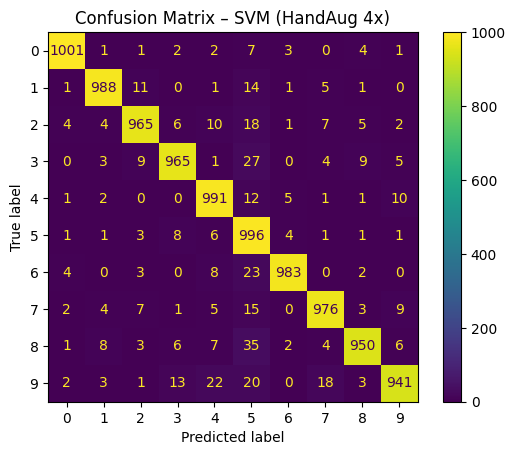

In [ ]:
import joblib
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
import matplotlib.pyplot as plt

# 저장된 모델 로드
model = joblib.load("pipeline_svm_HandAug_4x_Preprocessed_SVM.joblib")

# 예측
y_pred = model.predict(X_te)

# 정확도 출력
print(f"📌 Final Test Accuracy: {accuracy_score(y_te, y_pred):.4f}")

# Confusion Matrix 출력
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(y_te, y_pred)
plt.title("Confusion Matrix – SVM (HandAug 4x)")
plt.show()


취약 클래스만 추가 증강 -> weak_classes=[8,3,2,7,4,9]